*****Load major libraries:*****

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ready to go!")

Ready to go!


*****Check the filename:*****

In [2]:
import os
os.listdir('../data/')

['diabetic_data.csv']

*****Load and explore:*****

In [3]:
df = pd.read_csv('../data/diabetic_data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (101766, 50)

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


*****Check missing values:*****

In [4]:
# This dataset uses '?' for missing values
missing = (df == '?').sum()
print("Missing values (?):")
print(missing[missing > 0]) 

Missing values (?):
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


*****Check readmission distribution:*****

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


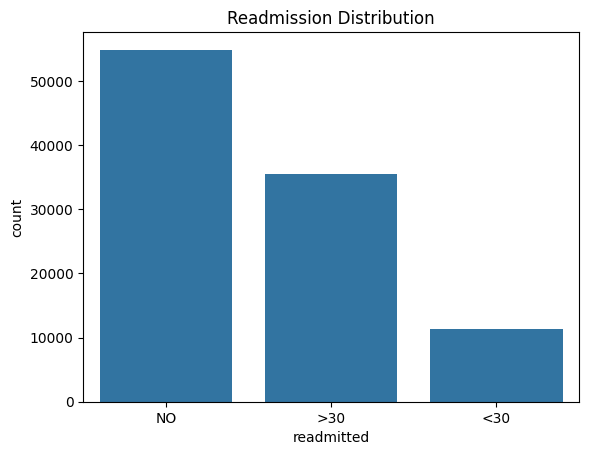

In [5]:
print(df['readmitted'].value_counts())

sns.countplot(x='readmitted', data=df)
plt.title('Readmission Distribution')
plt.show()

*****Dataset overview:*****

*****Clean data:***** 

In [6]:
# Drop columns with too many missing values
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])

# Remove rows with ? in diagnosis columns
df = df[df['diag_1'] != '?']
df = df[df['diag_2'] != '?']
df = df[df['diag_3'] != '?']

# Create binary target: 1 = readmitted early (<30), 0 = not
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("Clean shape:", df.shape)
print("Early readmission rate:", round(df['readmitted_binary'].mean() * 100, 2), "%")

Clean shape: (100244, 48)
Early readmission rate: 11.22 %


*****Readmission by age group:*****

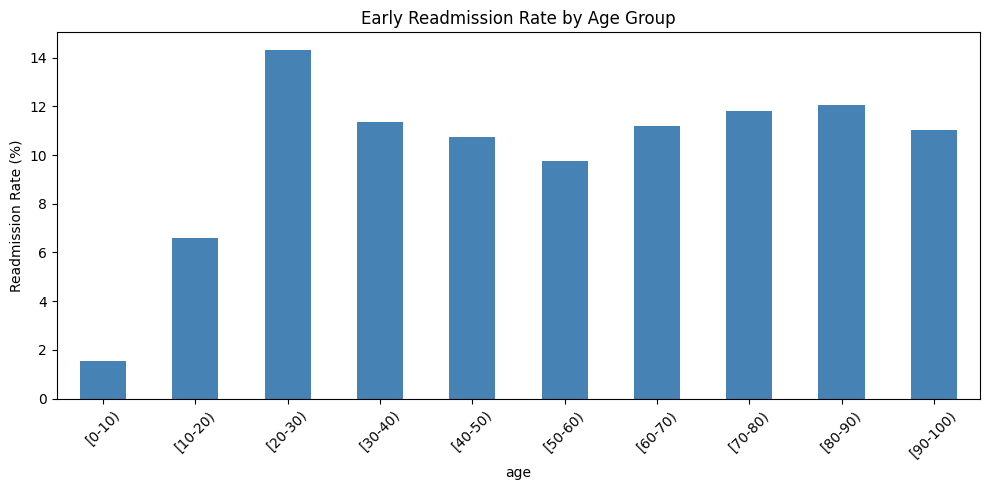

In [7]:
age_readmit = df.groupby('age')['readmitted_binary'].mean() * 100

age_readmit.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Early Readmission Rate by Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*****Readmission by time in hospital:*****

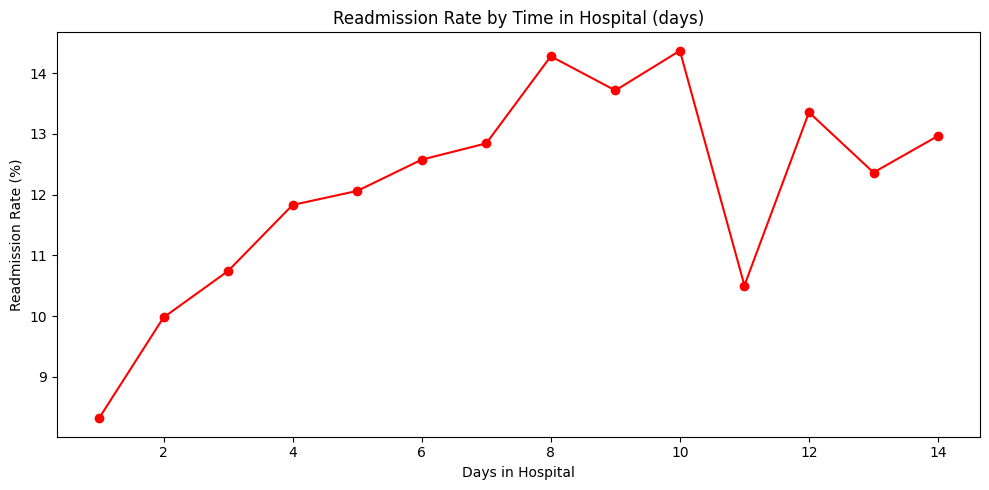

In [8]:
time_readmit = df.groupby('time_in_hospital')['readmitted_binary'].mean() * 100

time_readmit.plot(kind='line', figsize=(10,5), marker='o', color='red')
plt.title('Readmission Rate by Time in Hospital (days)')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Days in Hospital')
plt.tight_layout()
plt.show()

*****Key insights:*****

*****Build prediction model:*****

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and target
X = df.drop(columns=['readmitted', 'readmitted_binary', 'encounter_id', 'patient_nbr'])
y = df['readmitted_binary']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

C:\Users\HomePC\AppData\Local\Temp\ipykernel_22236\2094165136.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17814
           1       0.61      0.01      0.02      2235

    accuracy                           0.89     20049
   macro avg       0.75      0.50      0.48     20049
weighted avg       0.86      0.89      0.84     20049



*****Summary:*****

In [10]:
print("""
PROJECT 5 FINDINGS SUMMARY
===========================
Dataset: 100,244 diabetic patient records
Early Readmission Rate: 11.22%

Key Insights:
1. Age group 20-30 has highest readmission rate (14%)
2. Longer hospital stays increase readmission risk
3. Early identification can reduce hospital costs

Tools: Python, pandas, scikit-learn, seaborn
""")


PROJECT 5 FINDINGS SUMMARY
Dataset: 100,244 diabetic patient records
Early Readmission Rate: 11.22%

Key Insights:
1. Age group 20-30 has highest readmission rate (14%)
2. Longer hospital stays increase readmission risk
3. Early identification can reduce hospital costs

Tools: Python, pandas, scikit-learn, seaborn



*****Overall result:*****